# Gradus - Simulaciones del algoritmo Dual-Loop

Simulacion de 90 dias para 4 perfiles de estudiante con curva de aprendizaje real.
Items de cinturones bajos siempre tienen prioridad en sesion.

In [ ]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import date, timedelta
from dataclasses import dataclass, field

from algorithm import (
    SM2Config, SM2ItemState, update_item_state,
    is_graduated, build_session,
    should_reinsert, FunctionFamily, SkillType, ItemKey, SessionItem,
)

print('Imports OK')

Imports OK


## Cinturones y catalogo

In [2]:
BELT_ORDER = ['white', 'blue', 'violet', 'brown', 'black']

BELT_FUNCTIONS = {
    'white':  [FunctionFamily.LINEAR],
    'blue':   [FunctionFamily.QUADRATIC, FunctionFamily.POLYNOMIAL],
    'violet': [FunctionFamily.EXPONENTIAL, FunctionFamily.LOGARITHMIC],
    'brown':  [FunctionFamily.TRIGONOMETRIC],
    'black':  [FunctionFamily.RATIONAL],
}

BELT_COLORS = {
    'white': '#d1d5db', 'blue': '#3b82f6', 'violet': '#8b5cf6',
    'brown': '#a16207', 'black': '#374151',
}
BELT_LABELS = {
    'white': 'Blanco', 'blue': 'Azul', 'violet': 'Violeta',
    'brown': 'Marron', 'black': 'Negro',
}

FUNCTION_TO_BELT = {f: belt for belt, families in BELT_FUNCTIONS.items() for f in families}

# Catalogo ordenado por cinturon — define la prioridad de cada item en sesion
ORDERED_CATALOG = [
    ItemKey(function_family=family, skill_type=skill)
    for belt in BELT_ORDER
    for family in BELT_FUNCTIONS[belt]
    for skill in SkillType
]

# Mapa item -> prioridad (posicion en catalogo; menor = mas prioritario)
ITEM_PRIORITY = {key: idx for idx, key in enumerate(ORDERED_CATALOG)}

BELT_THRESHOLDS = {}
cumulative = 0
for belt in BELT_ORDER:
    cumulative += len(BELT_FUNCTIONS[belt]) * len(list(SkillType))
    BELT_THRESHOLDS[belt] = cumulative

print(f'Catalogo: {len(ORDERED_CATALOG)} items')
for belt in BELT_ORDER:
    n = len(BELT_FUNCTIONS[belt]) * 3
    print(f'  {BELT_LABELS[belt]}: {n} items ({BELT_THRESHOLDS[belt]} acumulados)')

Catalogo: 21 items
  Blanco: 3 items (3 acumulados)
  Azul: 6 items (9 acumulados)
  Violeta: 6 items (15 acumulados)
  Marron: 3 items (18 acumulados)
  Negro: 3 items (21 acumulados)


## Perfiles de estudiante

In [3]:
@dataclass
class StudentProfile:
    """
    Modela un perfil de estudiante con curva de aprendizaje real.

    p_fail decae con cada encuentro con el item:
        p_fail(n) = base_p_fail * max(0, 1 - n / mastery_encounters)
    """
    name: str
    color: str
    sessions_per_week: int
    base_p_fail: float
    mastery_encounters: int
    min_p_fail: float

    def p_fail_for(self, encounters: int) -> float:
        decay = max(0.0, 1.0 - encounters / self.mastery_encounters)
        return max(self.min_p_fail, self.base_p_fail * decay)

    def sample_quality(self, rng, encounters: int) -> int:
        p_fail = self.p_fail_for(encounters)
        if rng.random() < p_fail:
            return 1
        mastery = min(encounters / self.mastery_encounters, 1.0)
        w3 = 0.4 * (1 - mastery)
        w5 = 0.3 + 0.5 * mastery
        w4 = max(0.0, 1.0 - w3 - w5)
        return int(rng.choice([3, 4, 5], p=[w3, w4, w5]))

    def practice_days(self, total_days):
        days = set()
        if self.sessions_per_week == 4:
            offsets = [0, 2, 4, 6]
        elif self.sessions_per_week == 3:
            offsets = [0, 2, 4]
        else:
            offsets = [0, 3]
        week = 0
        while True:
            for off in offsets:
                d = week * 7 + off + 1
                if d > total_days:
                    return days
                days.add(d)
            week += 1


PROFILES = [
    StudentProfile(name='Casi perfecto', color='#16a34a', sessions_per_week=4,
                   base_p_fail=0.10, mastery_encounters=5,  min_p_fail=0.01),
    StudentProfile(name='Bueno',         color='#2563eb', sessions_per_week=4,
                   base_p_fail=0.25, mastery_encounters=8,  min_p_fail=0.03),
    StudentProfile(name='Promedio',      color='#d97706', sessions_per_week=3,
                   base_p_fail=0.45, mastery_encounters=14, min_p_fail=0.08),
    StudentProfile(name='Por debajo',    color='#dc2626', sessions_per_week=2,
                   base_p_fail=0.70, mastery_encounters=25, min_p_fail=0.15),
]

print('p_fail por encuentros (0 / 5 / 10 / 20)')
print('-' * 55)
for p in PROFILES:
    vals = [f'{p.p_fail_for(n):.0%}' for n in [0, 5, 10, 20]]
    print(f'{p.name:<15} | {" | ".join(vals)}')

p_fail por encuentros (0 / 5 / 10 / 20)
-------------------------------------------------------
Casi perfecto   | 10% | 1% | 1% | 1%
Bueno           | 25% | 9% | 3% | 3%
Promedio        | 45% | 29% | 13% | 8%
Por debajo      | 70% | 56% | 42% | 15%


## Motor de simulacion

In [4]:
def make_introduce_callback(items, requested):
    """
    Introduce items en orden de catalogo (cinturones bajos primero) sin gate estricto.
    La prioridad en sesion la maneja build_session via item_priority.
    """
    def introduce_new_item():
        for key in ORDERED_CATALOG:
            if key in items or key in requested:
                continue
            requested.add(key)
            return key
        return None
    return introduce_new_item


def simulate(profile, days=90, seed=42):
    rng = np.random.default_rng(seed)
    config = SM2Config()
    start_date = date(2026, 1, 1)
    items, practice_days_set = {}, profile.practice_days(days)
    daily_graduated, session_belt_counts, graduation_days = [], [], {}
    n_graduated = 0
    item_encounters = {}

    for day in range(1, days + 1):
        today = start_date + timedelta(days=day - 1)
        if day not in practice_days_set:
            daily_graduated.append(n_graduated)
            continue

        requested_this_session = set()
        session = build_session(
            items, today=today, config=config,
            introduce_new_item=make_introduce_callback(items, requested_this_session),
            item_priority=ITEM_PRIORITY,
        )

        for si in session:
            if si.key not in items:
                items[si.key] = SM2ItemState(
                    phase=si.state.phase, step_index=si.state.step_index,
                    ease_factor=si.state.ease_factor, interval=si.state.interval,
                    repetitions=si.state.repetitions, next_review=today,
                )

        queue = list(session)
        intra_counts, belt_counts = {}, {b: 0 for b in BELT_ORDER}

        while queue:
            si = queue.pop(0)
            key = si.key
            current_state = items[key]
            encounters = item_encounters.get(key, 0)
            quality = profile.sample_quality(rng, encounters)
            item_encounters[key] = encounters + 1
            new_state = update_item_state(current_state, quality, config=config, today=today)
            items[key] = new_state
            belt_counts[FUNCTION_TO_BELT[key.function_family]] += 1

            if new_state.phase == 'review' and current_state.phase == 'learning' and key not in graduation_days:
                graduation_days[key] = day
                n_graduated += 1

            if quality < config.quality_threshold_pass:
                count = intra_counts.get(key, 0)
                if should_reinsert(new_state, count, config=config):
                    intra_counts[key] = count + 1
                    queue.append(SessionItem(key=key, state=new_state))

        daily_graduated.append(n_graduated)
        session_belt_counts.append((day, belt_counts))

    white_keys = [k for k in ORDERED_CATALOG if FUNCTION_TO_BELT[k.function_family] == 'white']
    white_days = [graduation_days.get(k) for k in white_keys]
    time_to_blue = max(white_days) if all(d is not None for d in white_days) else None

    return {
        'daily_graduated': daily_graduated, 'session_belt_counts': session_belt_counts,
        'graduation_days': graduation_days, 'time_to_blue': time_to_blue,
        'items': items, 'practice_days': practice_days_set,
        'item_encounters': item_encounters,
    }

In [5]:
DAYS = 90
results = {}
for profile in PROFILES:
    results[profile.name] = simulate(profile, days=DAYS, seed=42)

print('Resumen a 90 dias\n' + '-' * 50)
for profile in PROFILES:
    r = results[profile.name]
    tb = r['time_to_blue']
    grad = r['daily_graduated'][-1]
    n_ses = len(r['session_belt_counts'])
    total_ex = sum(sum(c.values()) for _, c in r['session_belt_counts'])
    print(f'{profile.name}')
    print(f'  Sesiones        : {n_ses}')
    print(f'  Total ejercicios: {total_ex}')
    print(f'  Graduados       : {grad}/21')
    print(f'  Azul            : {"dia " + str(tb) if tb else "no alcanzado en " + str(DAYS) + " dias"}')
    print()

Resumen a 90 dias
--------------------------------------------------
Casi perfecto
  Sesiones        : 51
  Total ejercicios: 304
  Graduados       : 21/21
  Azul            : dia 5

Bueno
  Sesiones        : 51
  Total ejercicios: 313
  Graduados       : 21/21
  Azul            : dia 12

Promedio
  Sesiones        : 39
  Total ejercicios: 283
  Graduados       : 21/21
  Azul            : dia 15

Por debajo
  Sesiones        : 26
  Total ejercicios: 210
  Graduados       : 11/21
  Azul            : dia 32



## Grafico 1a - Items graduados acumulados (90 dias)

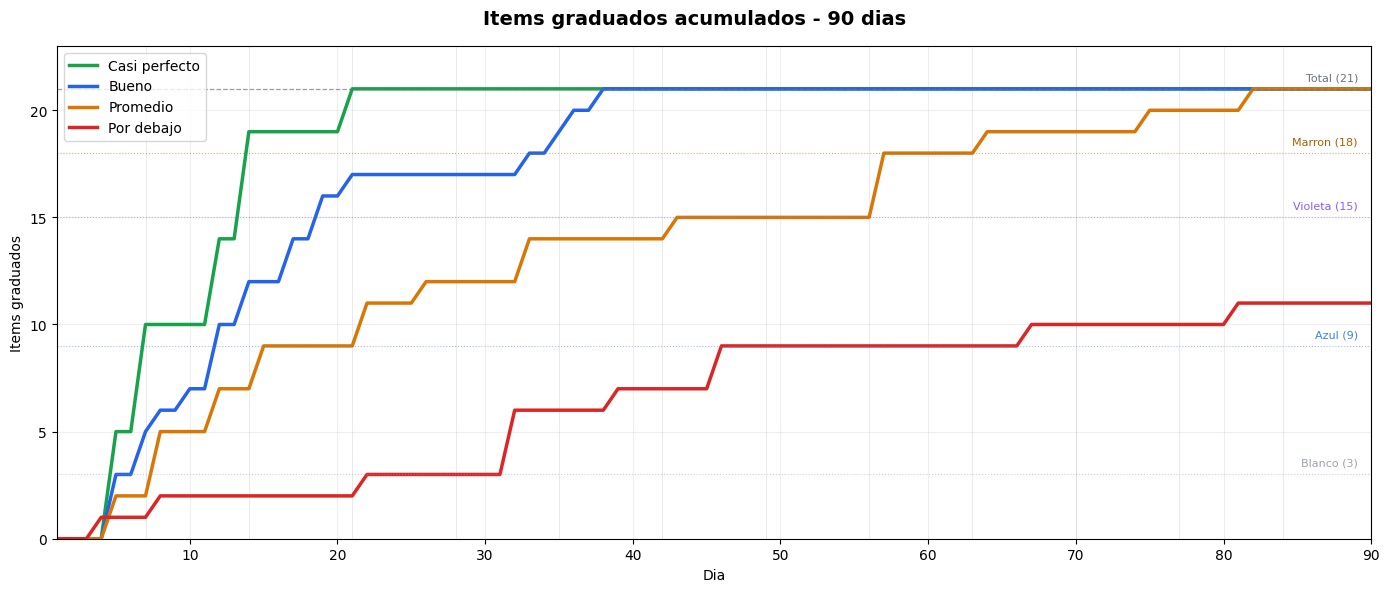

In [6]:
belt_ref = [
    (BELT_THRESHOLDS['white'],  '#9ca3af', 'Blanco (3)'),
    (BELT_THRESHOLDS['blue'],   '#3b82f6', 'Azul (9)'),
    (BELT_THRESHOLDS['violet'], '#8b5cf6', 'Violeta (15)'),
    (BELT_THRESHOLDS['brown'],  '#a16207', 'Marron (18)'),
]

days_x = list(range(1, DAYS + 1))
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Items graduados acumulados - 90 dias', fontsize=14, fontweight='bold')

for profile in PROFILES:
    ax.plot(days_x, results[profile.name]['daily_graduated'],
            color=profile.color, linewidth=2.5, label=profile.name)

ax.axhline(y=21, color='#6b7280', linestyle='--', linewidth=0.9, alpha=0.7)
ax.text(DAYS * 0.99, 21.4, 'Total (21)', ha='right', fontsize=8, color='#6b7280')
for y, color, label in belt_ref:
    ax.axhline(y=y, color=color, linestyle=':', linewidth=0.8, alpha=0.5)
    ax.text(DAYS * 0.99, y + 0.4, label, ha='right', fontsize=8, color=color)
for week in range(7, DAYS, 7):
    ax.axvline(x=week, color='#e5e7eb', linewidth=0.6, zorder=0)

ax.set_xlim(1, DAYS)
ax.set_ylim(0, 23)
ax.set_xlabel('Dia')
ax.set_ylabel('Items graduados')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Grafico 1b - Curva de aprendizaje por perfil

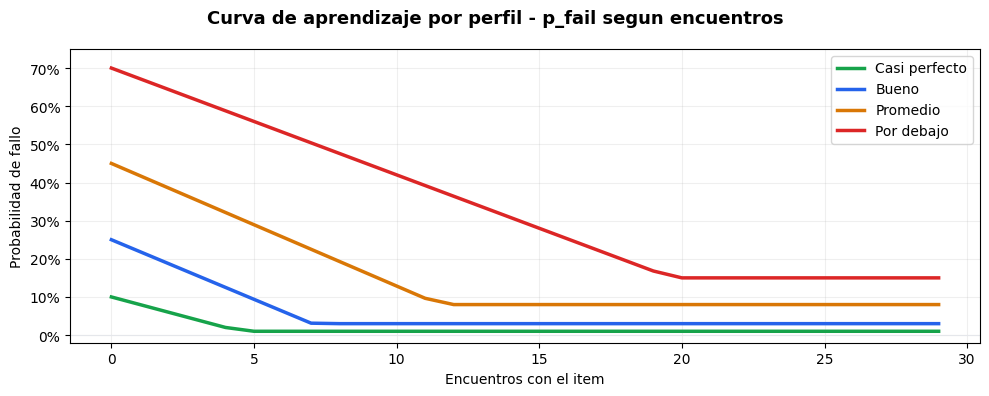

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle('Curva de aprendizaje por perfil - p_fail segun encuentros', fontsize=13, fontweight='bold')

enc_x = list(range(0, 30))
for profile in PROFILES:
    p_fails = [profile.p_fail_for(n) for n in enc_x]
    ax.plot(enc_x, p_fails, color=profile.color, linewidth=2.5, label=profile.name)

ax.axhline(y=0, color='#e5e7eb', linewidth=0.8)
ax.set_xlabel('Encuentros con el item')
ax.set_ylabel('Probabilidad de fallo')
ax.set_ylim(-0.02, 0.75)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Grafico 2 - Composicion de sesiones por cinturon (primeras 4 semanas)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_8528\1378230778.py:5: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=BELT_COLORS[b], label=BELT_LABELS[b], edgecolor='#e5e7eb', linewidth=0.5)


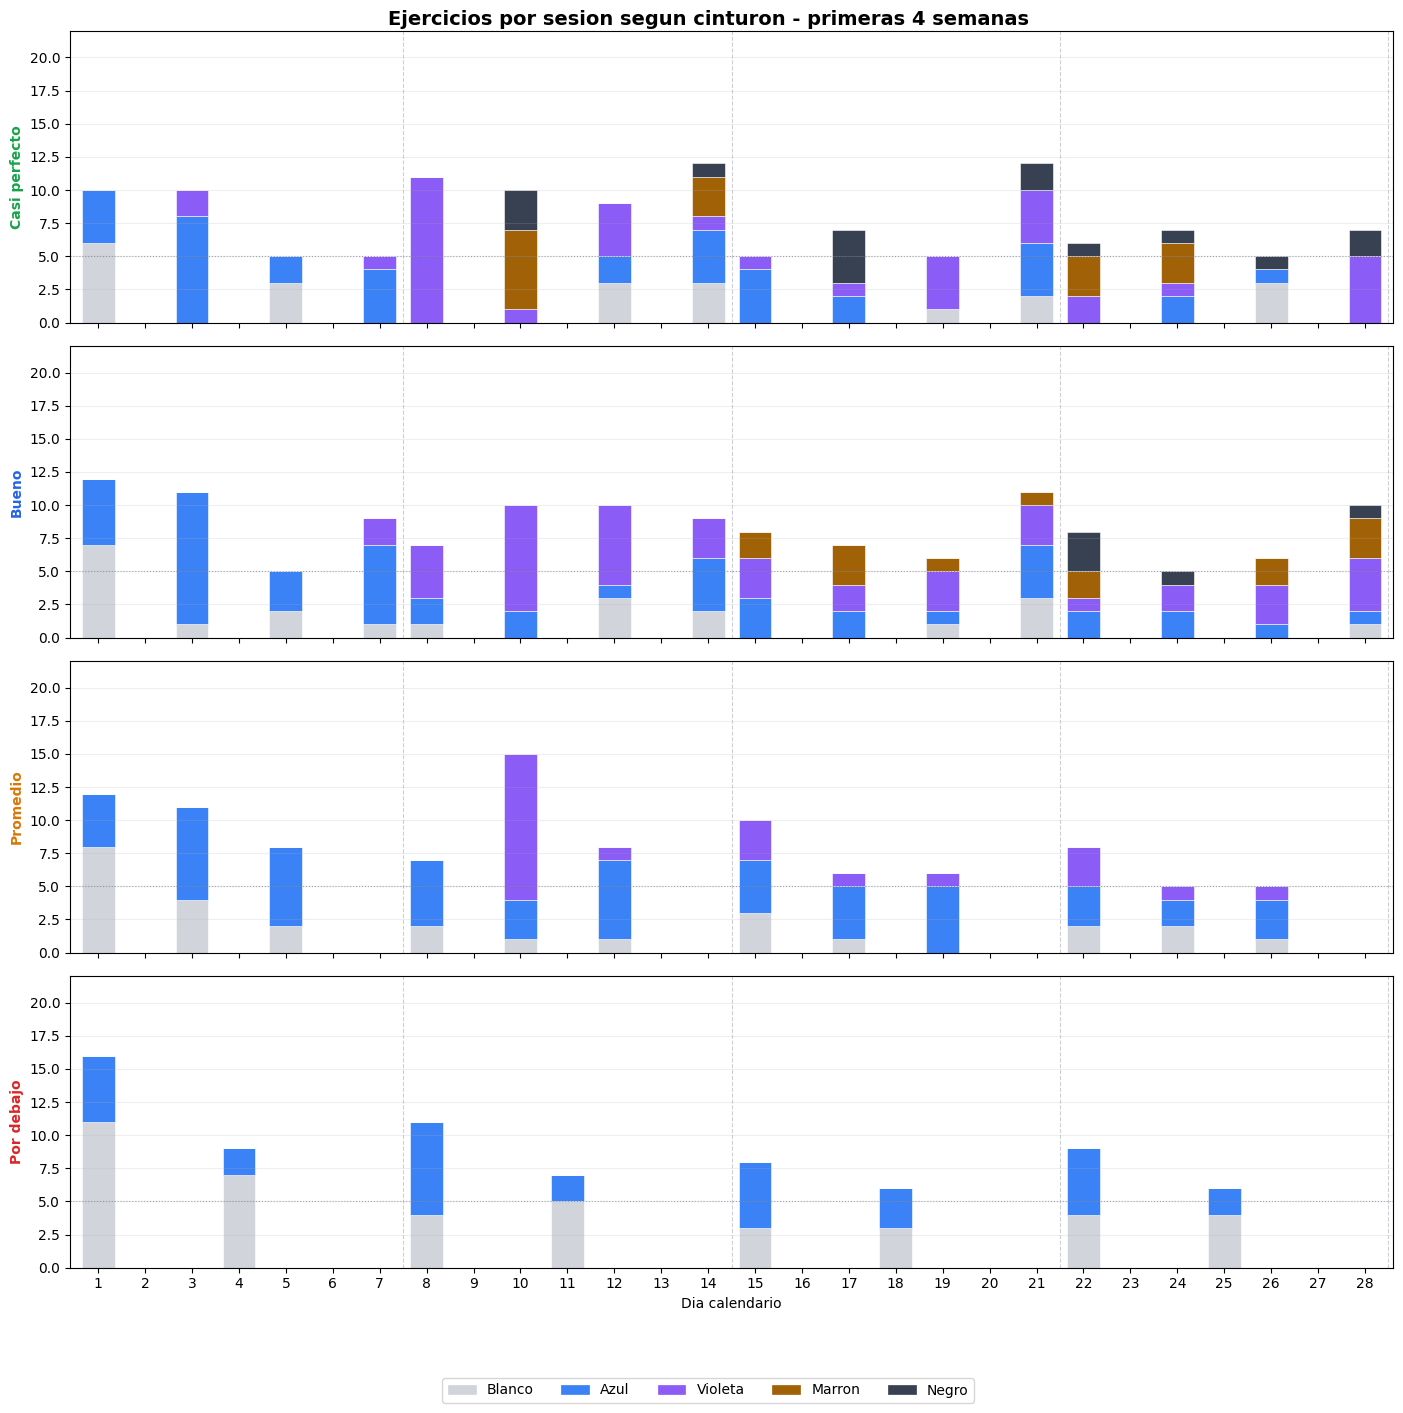

In [8]:
FIRST_N_DAYS = 28
days_x = list(range(1, FIRST_N_DAYS + 1))

legend_patches = [
    mpatches.Patch(color=BELT_COLORS[b], label=BELT_LABELS[b], edgecolor='#e5e7eb', linewidth=0.5)
    for b in BELT_ORDER
]

fig, axes = plt.subplots(len(PROFILES), 1, figsize=(14, 14), sharex=True)
fig.suptitle('Ejercicios por sesion segun cinturon - primeras 4 semanas', fontsize=14, fontweight='bold')

for ax, profile in zip(axes, PROFILES):
    r = results[profile.name]
    day_belt = {d: {b: 0 for b in BELT_ORDER} for d in range(1, FIRST_N_DAYS + 1)}
    for day, counts in r['session_belt_counts']:
        if day <= FIRST_N_DAYS:
            day_belt[day] = counts

    bottoms = [0] * FIRST_N_DAYS
    for belt in BELT_ORDER:
        values = [day_belt[d][belt] for d in days_x]
        ax.bar(days_x, values, bottom=bottoms,
               color=BELT_COLORS[belt], edgecolor='white', linewidth=0.4, width=0.7)
        bottoms = [b + v for b, v in zip(bottoms, values)]

    ax.axhline(y=5, color='#6b7280', linestyle=':', linewidth=0.8, alpha=0.6)
    for week in range(7, FIRST_N_DAYS + 1, 7):
        ax.axvline(x=week + 0.5, color='#9ca3af', linewidth=0.8, linestyle='--', alpha=0.5)

    ax.set_ylabel(profile.name, color=profile.color, fontweight='bold', fontsize=10)
    ax.set_ylim(0, 22)
    ax.grid(True, alpha=0.2, axis='y')

axes[-1].set_xlabel('Dia calendario')
axes[-1].set_xticks(days_x)
axes[-1].set_xlim(0.4, FIRST_N_DAYS + 0.6)
fig.legend(handles=legend_patches, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.02), frameon=True, fontsize=10)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## Grafico 3 - Tiempo hasta cinturon azul

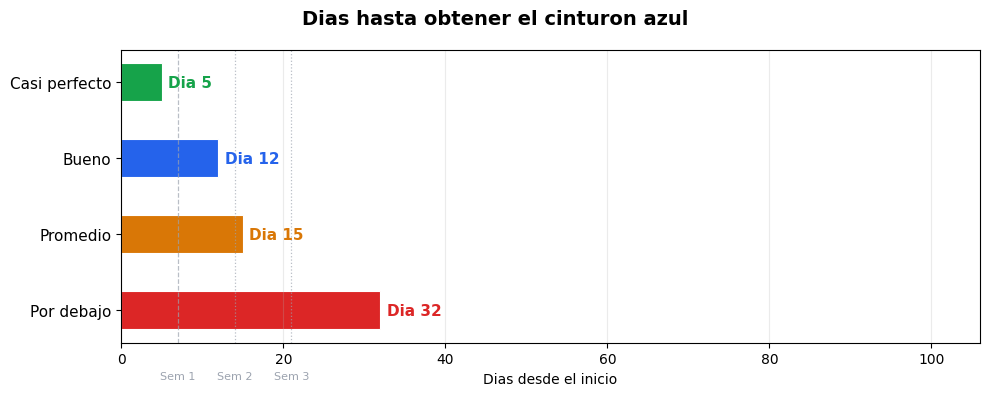

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle('Dias hasta obtener el cinturon azul', fontsize=14, fontweight='bold')

y_pos = list(range(len(PROFILES)))
bar_values, bar_colors, bar_labels = [], [], []
for profile in PROFILES:
    tb = results[profile.name]['time_to_blue']
    bar_values.append(tb if tb is not None else DAYS)
    bar_colors.append(profile.color)
    bar_labels.append(f'Dia {tb}' if tb is not None else f'No alcanzado ({DAYS} dias)')

bars = ax.barh(y_pos, bar_values, color=bar_colors, height=0.5, edgecolor='white', linewidth=0.8)
for bar, label, profile in zip(bars, bar_labels, PROFILES):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
            label, va='center', fontsize=11, fontweight='bold', color=profile.color)

ax.set_yticks(y_pos)
ax.set_yticklabels([p.name for p in PROFILES], fontsize=11)
ax.set_xlabel('Dias desde el inicio')
ax.set_xlim(0, DAYS + 16)
ax.invert_yaxis()
for week, style in [(7, '--'), (14, ':'), (21, ':')]:
    ax.axvline(x=week, color='#9ca3af', linestyle=style, linewidth=0.9, alpha=0.7)
    ax.text(week, len(PROFILES) - 0.1, f'Sem {week // 7}', ha='center', fontsize=8, color='#9ca3af')
ax.grid(True, alpha=0.25, axis='x')
plt.tight_layout()
plt.show()